In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import requests
from pathlib import Path
from datetime import datetime, timedelta
import time

In [2]:
raw_data=pd.read_csv("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/agri_bio_papers_2018_2023.csv")

In [3]:
raw_data.shape

(1819291, 16)

In [7]:
raw_data.columns

Index(['doi', 'publication_year', 'author_count', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'corresponding_author_hindex_at_pub',
       'source_id', 'source_display_name', 'source_2yr_mean_citedness',
       'source_type', 'apc_list_value_usd', 'primary_topic_id',
       'primary_topic_display_name', 'referenced_works_count'],
      dtype='str')

In [ ]:
raw_data.source_type.value_counts()

source_type
journal           1460485
repository         172580
conference          33701
book series          2523
ebook platform        100
other                  18
Name: count, dtype: int64

In [23]:
raw_data.type.value_counts()

AttributeError: 'DataFrame' object has no attribute 'type'

In [15]:
raw_data.source_display_name.value_counts().head(100)

source_display_name
Zenodo (CERN European Organization for Nuclear Research)              26365
IOP Conference Series Earth and Environmental Science                 19447
DOAJ (DOAJ: Directory of Open Access Journals)                        19397
International Journal of Current Microbiology and Applied Sciences    10780
SSRN Electronic Journal                                                9931
                                                                      ...  
Viruses                                                                1429
Applied Ecology and Environmental Research                             1417
Faculty of 1000 Research Ltd                                           1417
CATENA                                                                 1409
Agriculture Ecosystems & Environment                                   1377
Name: count, Length: 100, dtype: int64

In [20]:
top_100_sources=raw_data.source_display_name.value_counts().head(100).index
top_100_by_papers = raw_data[raw_data["source_display_name"].isin(top_100_sources)]
top_100_by_papers.source_display_name.iloc[top_100_by_papers.source_type=="journal"].value_counts().tail(20)

source_display_name
Computers and Electronics in Agriculture                   1696
Food Science and Technology                                1684
Frontiers in Veterinary Science                            1656
Pest Management Science                                    1645
Abstracts with programs - Geological Society of America    1638
PLANT PHYSIOLOGY                                           1634
Ecology and Evolution                                      1626
AGU Fall Meeting Abstracts                                 1609
Agricultural Water Management                              1597
South African Journal of Botany                            1584
Journal of Experimental Botany                             1577
Veterinary Record                                          1574
Agronomy Journal                                           1561
The Indian Journal of Agricultural Sciences                1550
Food Control                                               1481
Journal of Agricultu

In [22]:
raw_data.loc[raw_data.source_display_name == "DOAJ (DOAJ: Directory of Open Access Journals)"]

,doi,publication_year,author_count,countries_distinct_count,institutions_distinct_count,corresponding_author_ids,corresponding_institution_ids,corresponding_author_hindex_at_pub,source_id,source_display_name,source_2yr_mean_citedness,source_type,apc_list_value_usd,primary_topic_id,primary_topic_display_name,referenced_works_count
204,https://doi.org/10.2478/ausi-2018-0002,2018,2,1,2,A5109616840,I3125347698,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T10616,Smart Agriculture and AI,24
1624,https://doi.org/10.14601/phytopathol_mediterr-...,2018,3,0,3,A5080999810,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T14018,Agriculture and Biological Studies,0
2859,NaN,2018,2,0,2,A5008071693,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T12657,Phytochemistry Medicinal Plant Applications,0
3729,https://doi.org/10.22090/jwent.2018.01.003,2018,6,1,6,A5112292854,I1516879,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T12113,Growth and nutrition in plants,0
8293,https://doi.org/10.22038/ajp.2018.15338.1607,2018,4,1,4,A5020639473,I165560825|I4210088961,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T11613,Phytochemistry and Biological Activities,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819260,NaN,2023,1,0,1,A5091893093,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T14124,"Food, Nutrition, and Cultural Practices",0
1819261,NaN,2023,1,0,1,A5068818479,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T11925,Culinary Culture and Tourism,0
1819264,NaN,2023,1,0,1,A5137455154,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T14124,"Food, Nutrition, and Cultural Practices",0
1819265,NaN,2023,1,0,1,A5045880655,NaN,NaN,S4306401280,DOAJ (DOAJ: Directory of Open Access Journals),NaN,repository,NaN,T14398,Agriculture and Social Issues,0


In [ ]:
raw_data.source_type.value_counts()

source_type
journal           1002743
repository          98192
conference          24090
book series          1903
ebook platform         71
other                   6
Name: count, dtype: int64

In [ ]:
journals=raw_data.source_display_name.unique().tolist()
journals_raw_data=pd.DataFrame(journals, columns=['journal_name'])
journals_raw_data.to_csv("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/journals.csv", index=False)

In [ ]:

# Load the CSV file
raw_data = pd.read_csv("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/peer_reviewed_journals_filtered.csv")

# Convert the column into a Python list with quotes and commas
peer_reviewed= [
    f"'{journal}',"
    for journal in raw_data["peer_reviewed_journal"].dropna().unique()
]

# Print the result
for journal in peer_reviewed:
    print(journal)

'"Ovidius" University Annals. Series Civil Engineering/Analele Universităţii "Ovidius" Constanţa. Seria Construcţii',
'(IJRE) International Journal of Research and Ethics (ISSN 2665-7481)',
'03.02 - Airway cell biology and immunopathology',
'2020 Advances in Science and Engineering Technology International Conferences (ASET)',
'2022 Advances in Science and Engineering Technology International Conferences (ASET)',
'2022 IEEE Intl Conf on Dependable, Autonomic and Secure Computing, Intl Conf on Pervasive Intelligence and Computing, Intl Conf on Cloud and Big Data Computing, Intl Conf on Cyber Science and Technology Congress (DASC/PiCom/CBDCom/CyberSciTech)',
'3BIO Journal of Biological Science Technology and Management',
'3L The Southeast Asian Journal of English Language Studies',
'A breakthrough in science: development strategies',
'A/Z ITU journal of Faculty of Architecture',
'AAPG Bulletin',
'AASA journal of scholarship & practice',
'AATCC Journal of Research',
'ABAC Journal',
'ABC J

In [ ]:
# peer_reviewed = {'Global Change Biology',
# 'Food Security',
# 'Geoderma Regional',
# 'Agronomy Journal',
# 'Journal of Soil and Water Conservation',
# 'Soil and Tillage Research',
# 'Philosophical Transactions of the Royal Society B Biological Sciences',
# 'Current Climate Change Reports',
# 'Soil Science & Plant Nutrition',
# 'Soil Systems',
# 'International Soil and Water Conservation Research',
# 'Geoderma',
# 'South African Journal of Plant and Soil',
# 'Frontiers in Sustainable Food Systems',
# 'European Journal of Soil Science',
# 'Pedosphere',
# 'Climate Change',
# 'Applied Sciences',
# 'Crop Science',
# 'Current Sustainable/Renewable Energy Reports',
# 'Nature Communications',
# 'Soil Biology and Biochemistry',
# 'Science of the Total Environment',
# 'Land Degradation and Development',
# 'Earth-Science Reviews',
# 'Frontiers of Agricultural Science and Engineering',
# 'Biogeosciences',
# 'Trends in Plant Science',
# 'Journal of Integrative Agriculture',
# 'Annual Review of Environment and Resources',
# 'Agriculture, Ecosystems & Environment',
# 'Philosophical Transactions of the Royal Society A',
# 'Earth System Science Data',
# 'Proceedings of the Royal Society B',
# 'GCB Bioenergy',
# 'Veterinary Record',
# 'One Earth',
# 'Architectural History',
# 'Journalism History',
# 'Australian Forestry',
# 'Nature Reviews Earth & Environment',
# 'Nature Geoscience',
# 'Communications Biology',
# 'Geochimica et Cosmochimica Acta',
# 'Palgrave Communications',
# 'ACS Sustainable Chemistry & Engineering',
# 'Waste Management',
# 'Nature',
# 'Journal of Environmental Quality',
# 'Scientific Reports',
# 'New Phytologist',
# 'Chemosphere',
# 'Applied Soil Ecology',
# 'Nutrient Cycling in Agroecosystems',
# 'Biochar',
# 'Soil Science',
# 'PLOS Global Public Health',
# 'Water',
# 'Ecology Letters',
# 'Frontiers in Microbiology',
# 'Frontiers in Plant Science',  
# 'Frontiers in Agronomy',
# 'PLoS ONE',
# 'Journal of Agricultural and Food Chemistry',
# 'Journal of Plant Nutrition and Soil Science',
# 'Plant and Soil',
# 'Journal of Cereal Science',
# 'Panoeconomicus',
# 'Annual Review of Ecology, Evolution, and Systematics',
# 'Nature Reviews Microbiology',
# 'Science Advances',
# 'Nature Microbiology',
# 'Field Crops Research',
# 'Environmental Science & Technology',
# 'Functional Ecology',
# 'Journal of Applied Ecology',
# 'SOIL',
# 'Nature Sustainability',
# 'Science',
# 'Global Sustainability',
# 'International Journal of Environmental Research and Public Health',
# 'Agriculture and Human Values',
# 'Respirology',
# 'Sustainability',
# 'Geoscientific Model Development',
# 'AMBIO',
# 'Earth’s Future',
# 'Outlook on Agriculture',
# 'NJAS – Wageningen Journal of Life Sciences',
# 'Global Food Security',
# 'Agricultural Systems',
# 'Ecosystem Services',
# 'Journal of Agricultural Education and Extension',
# 'Environmental Innovation and Societal Transitions',
# 'Food Policy',
# 'Journal of Rural Studies',
# 'Sociologia Ruralis',
# 'International Journal of Agricultural Sustainability',
# 'New Zealand Economic Papers',
# 'Journal of Technology Management & Innovation',
# 'Agriculture',
# 'Journal of Environmental Management',
# 'Agricultural Water Management',
# 'Industrial Crops and Products',
# 'Human and Ecological Risk Assessment',
# 'Scientia Horticulturae',
# 'Environmental Science and Pollution Research',
# 'Environmental Monitoring and Assessment',
# 'Journal of Soil Science and Plant Nutrition',
# 'Weed Biology and Management',
# 'Plant Science',
# 'Pest Management Science',
# 'Biological Agriculture & Horticulture',
# 'Environment, Development and Sustainability',
# 'Crop Protection',
# 'Journal of Plant Growth Regulation',
# 'Biologia',
# 'International Journal of Pest Management',
# 'Renewable and Sustainable Energy Reviews',
# 'Land Use Policy',
# 'Horticulturae',
# 'Weed Technology',
# 'Plant Species Biology',
# 'Experimental Agriculture',
# 'National Science Review',
# 'Environmental Pollution',
# 'The Crop Journal',
# 'Atmospheric Chemistry and Physics',
# 'European Journal of Agronomy',
# 'Food and Energy Security',
# 'Frontiers in Nutrition',
# 'Critical Reviews in Environmental Science and Technology',
# 'Remote Sensing',
# 'Biogeochemistry',
# 'Journal of Hydrology',
# 'Soil Security',
# 'CATENA',
# 'Remote Sensing: Applications Society and Environment',
# 'FEMS Microbiology Ecology',
# 'Soil Science Society of America Journal',
# 'Grass and Forage Science',
# 'CABI Reviews',
# 'Agricultural & Environmental Letters',
# 'Agronomy',
# 'Journal of Animal Science',
# 'Italian Journal of Agronomy',
# 'Frontiers in Climate',
# 'Frontiers in Environmental Science',
# 'Communications Earth & Environment',
# 'Physica Scripta',
# 'Journal of Hazardous Materials Advances',
# 'BMC Plant Biology',
# 'International Journal of Molecular Sciences',
# 'Plant Physiology and Biochemistry',
# 'Biology',
# 'Materials Today Bio',
# 'Nature Plants',
# 'Current Opinion in Plant Biology',
# 'Functional Plant Biology',
# 'Cells',
# 'Proteomes',
# 'Physiologia Plantarum',
# 'Plant Stress',
# 'Plants',
# 'Frontiers in Genetics',
# 'Hydrology and Earth System Sciences',
# 'Environmental and Experimental Botany',
# 'Genes',
# 'Journal of Proteomics',
# 'Cahiers Agricultures',
# 'ISPRS Journal of Photogrammetry and Remote Sensing',
# 'E&G Quaternary Science Journal',
# 'Climate of the Past',
# 'Technical Gazette',
# 'American Naturalist',
# 'Biodiversitas',
# 'Ecology and Evolution',
# 'Royal Society Open Science',
# 'Journal of Experimental Botany',
# 'Elementa: Science of the Anthropocene',
# 'Nature Food',
# 'The Lancet Planetary Health',
# 'Nature Human Behaviour',
# 'European Journal of Integrative Medicine',
# 'Renewable Energy',
# 'Acta Crystallographica Section A',
# 'Journal of Cleaner Production',
# 'Italian Journal of Food Science',
# 'Open Agriculture',
# 'AGROFOR',
# 'New Medit',
# 'Land',
# 'Evolutionary Applications',
# 'Crop and Pasture Science',
# 'Molecules',
# 'Environmental Science: Nano',
# 'Plant Physiology',
# 'Environment International',
# 'Annals of Botany',
# 'Anthropocene Science',
# 'Irrigation Science',
# 'Water Resources Management',
# 'Sleep Science',
# 'Sensors and Actuators A',
# 'TrAC Trends in Analytical Chemistry',
# 'Computers and Electronics in Agriculture',
# 'Sensors',
# 'Reviews in Aquaculture',
# 'Aquaculture',
# 'IEEE Access',
# 'Frontiers in Bioengineering and Biotechnology',
# 'Journal of Marine Science and Engineering',
# 'Artificial Intelligence Review',
# 'Critical Reviews in Analytical Chemistry',
# 'Biosystems Engineering',
# 'Journal of the World Aquaculture Society',
# 'Aquacultural Engineering',
# 'Animals',
# 'Water Science & Technology',
# 'Information Processing in Agriculture',
# 'ICES Journal of Marine Science',
# 'Fishes',
# 'Biosensors',
# 'Engineering Applications of Artificial Intelligence',
# 'Sensors and Actuators B',
# 'Measurement',
# 'Nanomaterials',
# 'Environmental Research Letters',
# 'Expert Systems with Applications',
# 'Multimedia Tools and Applications',
# 'Analytical Methods',
# 'Energies',
# 'Spectroscopy Letters',
# 'Construction and Building Materials',
# 'Soil Research',
# 'Journal of Green Building',
# 'Critical Reviews in Biotechnology',
# 'Applied Microbiology and Biotechnology',
# 'Food Chemistry',
# 'Current Genomics',
# 'Acta Physiologiae Plantarum',
# 'Natural Resources Forum',
# 'Trends in Food Science & Technology',
# 'International Food and Agribusiness Management Review',
# 'Ecological Engineering',
# 'Environmental Research',
# 'Energy',
# 'Energy Ecology and Environment',
# 'Atmospheric Pollution Research',
# 'Indian Journal of Agricultural Sciences',
# 'Frontiers in Sociology',
# 'Environmental Challenges',
# 'International Journal of Water Resources Development',
# 'Climate and Development',
# 'Frontiers in Public Health',
# 'Nature-Based Solutions',
# 'Journal of Development Effectiveness',
# 'Acta Oecologica',
# 'Global Ecology and Biogeography',
# 'Freshwater Science',
# 'Agrosystems, Geosciences & Environment',
# 'Current Forestry Reports',
# 'Environmental Microbiology',
# 'Forests',
# 'Diversity',
# 'European Journal of Soil Biology',
# 'Journal of Insect Behavior',
# 'Eurasian Soil Science',
# 'Agronomy for Sustainable Development',
# 'Journal of Plant Physiology',
# 'Journal of Hazardous Materials',
# 'Journal of Plant Nutrition',
# 'Silicon',
# 'Environmental Technology & Innovation',
# 'Spatial Statistics',
# 'Biology and Fertility of Soils',
# 'Carbon Management',
# 'Organic Geochemistry',
# 'Regional Environmental Change',
# 'Journal of Soils and Sediments',
# 'Nature Climate Change',
# 'Global Biogeochemical Cycles',
# 'Research Synthesis Methods',
# 'Extremes',
# 'Environmental Evidence',
# 'Journal of Eukaryotic Microbiology',
# 'Ecological Indicators',
# 'Acta Entomologica Musei Nationalis Pragae'}

In [ ]:
def normalize(x):
    return str(x).strip().lower()

peer_reviewed_norm = {normalize(j) for j in peer_reviewed}

raw_data_filtered = raw_data[
    raw_data["source_display_name"].apply(normalize).isin(peer_reviewed_norm)
].copy()
print(raw_data_filtered.source_display_name.isna().sum())
raw_data_filtered.shape

KeyError: 'source_display_name'

In [ ]:
#Extract 2 year exact citation

def get_exact_2y_cites(
    raw_data_processed,
    id_col="openalex_id",
    date_col="publication_date",
    email=None,
    sleep=0.12,
    checkpoint_path=None,
    save_every=100,
    timeout=20,
    max_retries=4,
):
    """
    Compute exact citation windows per paper using OpenAlex API.

    Appends to raw_data_processed:
      - citations_year_1_exact: from publication day to +364 days
      - citations_year_2_exact: from +365 to +729 days
      - citations_first_2y_exact: year_1 + year_2

    Designed for large batches with resume/checkpoint support.
    """

    base_url = "https://api.openalex.org/works"
    session = requests.Session()
    user_agent = f"mailto:{email}" if email else "OpenAlex-Exact2Y-Citations"
    session.headers.update({"User-Agent": user_agent})

    def _normalize_work_id(work_id):
        s = str(work_id).strip()
        if s.startswith("http"):
            s = s.rstrip("/").split("/")[-1]
        return s

    def _query_count(short_id, from_dt, to_dt):
        params = {
            "filter": f"cites:{short_id},from_publication_date:{from_dt},to_publication_date:{to_dt}",
            "select": "id",
            "per_page": 1,
        }
        if email:
            params["mailto"] = email

        for attempt in range(1, max_retries + 1):
            try:
                resp = session.get(base_url, params=params, timeout=timeout)
                status = resp.status_code
                if status in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(f"HTTP {status}: retryable")
                resp.raise_for_status()
                count = resp.json().get("meta", {}).get("count", 0)
                return int(count) if count is not None else 0
            except Exception as e:
                if attempt == max_retries:
                    print(f"ERROR final ({short_id}): {e}")
                    return np.nan
                backoff = (2 ** (attempt - 1)) * sleep + random.uniform(0, sleep)
                time.sleep(backoff)
        return np.nan

    # Pre-normalize work IDs once for efficient lookups
    work_ids_short = raw_data_processed[id_col].astype(str).map(_normalize_work_id)

    # Resume from checkpoint if available
    cached = {}
    cp = Path(checkpoint_path) if checkpoint_path else None
    if cp and cp.exists():
        cp_raw_data_processed = pd.read_csv(cp)
        required_cache_cols = {
            id_col,
            "citations_year_1_exact",
            "citations_year_2_exact",
            "citations_first_2y_exact",
        }
        if required_cache_cols.issubset(set(cp_raw_data_processed.columns)):
            cp_ids_short = cp_raw_data_processed[id_col].astype(str).map(_normalize_work_id)
            for short_id, y1, y2, total in zip(
                cp_ids_short,
                cp_raw_data_processed["citations_year_1_exact"],
                cp_raw_data_processed["citations_year_2_exact"],
                cp_raw_data_processed["citations_first_2y_exact"],
            ):
                cached[short_id] = (y1, y2, total)
            print(f"Loaded checkpoint with {len(cached)} papers from {cp}")

    results = dict(cached)
    total = len(raw_data_processed)
    processed_now = 0

    for i, (short_id, pub_date_str) in enumerate(zip(work_ids_short, raw_data_processed[date_col]), 1):
        if short_id in results and not any(pd.isna(v) for v in results[short_id]):
            if i % 200 == 0 or i == total:
                print(f"  progress: {i}/{total} (cached/resumed)")
            continue

        try:
            pub_date = datetime.strptime(str(pub_date_str), "%Y-%m-%d")
        except Exception:
            results[short_id] = (np.nan, np.nan, np.nan)
            continue

        y1_start = pub_date
        y1_end = pub_date + timedelta(days=364)
        y2_start = pub_date + timedelta(days=365)
        y2_end = pub_date + timedelta(days=729)

        y1_count = _query_count(short_id, y1_start.strftime("%Y-%m-%d"), y1_end.strftime("%Y-%m-%d"))
        y2_count = _query_count(short_id, y2_start.strftime("%Y-%m-%d"), y2_end.strftime("%Y-%m-%d"))

        if pd.isna(y1_count) or pd.isna(y2_count):
            total_2y = np.nan
        else:
            total_2y = int(y1_count) + int(y2_count)

        results[short_id] = (y1_count, y2_count, total_2y)
        processed_now += 1

        # Save incremental checkpoint for large runs
        if cp and (processed_now % save_every == 0):
            tmp = pd.DataFrame([
                {
                    id_col: k,
                    "citations_year_1_exact": v[0],
                    "citations_year_2_exact": v[1],
                    "citations_first_2y_exact": v[2],
                }
                for k, v in results.items()
            ])
            tmp.to_csv(cp, index=False)
            print(f"  checkpoint saved: {len(tmp)} rows")

        time.sleep(sleep)

        if i % 25 == 0 or i == total:
            print(f"  progress: {i}/{total}")

    lookup = work_ids_short.map(lambda k: results.get(k, (np.nan, np.nan, np.nan)))
    raw_data_processed["citations_year_1_exact"] = lookup.map(lambda v: v[0])
    raw_data_processed["citations_year_2_exact"] = lookup.map(lambda v: v[1])
    raw_data_processed["citations_first_2y_exact"] = lookup.map(lambda v: v[2])

    # Final checkpoint write
    if cp:
        final_cp = pd.DataFrame({
            id_col: work_ids_short,
            "citations_year_1_exact": raw_data_processed["citations_year_1_exact"],
            "citations_year_2_exact": raw_data_processed["citations_year_2_exact"],
            "citations_first_2y_exact": raw_data_processed["citations_first_2y_exact"],
        }).drop_duplicates(subset=[id_col], keep="first")
        final_cp.to_csv(cp, index=False)
        print(f"Final checkpoint saved to {cp}")

    return raw_data_processed

# Apply exact 2-year enrichment (resume-safe for large collections)
checkpoint_file = Path("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml")

get_exact_2y_cites(
    raw_data_filtered,
    id_col="openalex_id",
    date_col="publication_date",
    email=None,
    sleep=0.12,
    checkpoint_path=checkpoint_file,
    save_every=100,
    timeout=20,
    max_retries=4,
)

Loaded checkpoint with 3959 papers from /home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml
  progress: 200/4268 (cached/resumed)
  progress: 400/4268 (cached/resumed)
  progress: 600/4268 (cached/resumed)
  progress: 800/4268 (cached/resumed)
  progress: 1000/4268 (cached/resumed)
  progress: 1200/4268 (cached/resumed)
  progress: 1400/4268 (cached/resumed)
  progress: 1600/4268 (cached/resumed)
  progress: 1800/4268 (cached/resumed)
  progress: 2000/4268 (cached/resumed)
  progress: 2200/4268 (cached/resumed)
  progress: 2400/4268 (cached/resumed)
  progress: 2600/4268 (cached/resumed)
  progress: 2800/4268 (cached/resumed)
  progress: 3000/4268 (cached/resumed)
  progress: 3200/4268 (cached/resumed)
  progress: 3400/4268 (cached/resumed)
  progress: 3600/4268 (cached/resumed)
  progress: 3800/4268 (cached/resumed)
  progress: 4000/4268 (cached/resumed)
  progress: 4200/4268 (cached/resumed)
  progress: 4268/4268 (cached/resumed)
Final checkpoint sav

,openalex_id,openalex_url,doi,title,publication_year,publication_date,type,cited_by_count,fwci,citation_percentile_value,...,primary_field_name,all_topics,keywords,sustainable_development_goals,referenced_works_count,referenced_works,related_works,citations_year_1_exact,citations_year_2_exact,citations_first_2y_exact
0,W2790329997,https://openalex.org/W2790329997,https://doi.org/10.1111/gcb.14054,Digging deeper: A holistic perspective of fact...,2018,2018-01-17,review,837,47.3177,0.999450,...,Agricultural and Biological Sciences,"[{""id"": ""https://openalex.org/T10004"", ""displa...","[{""id"": ""https://openalex.org/keywords/environ...","[{""score"": 0.5, ""display_name"": ""Life in Land""...",180,"[""https://openalex.org/W8421042"", ""https://ope...","[""https://openalex.org/W4403077800"", ""https://...",18,37,55
1,W3095638759,https://openalex.org/W3095638759,https://doi.org/10.1038/s41467-020-18887-7,Towards a global-scale soil climate mitigation...,2020,2020-10-27,review,750,55.1529,0.999715,...,Agricultural and Biological Sciences,"[{""id"": ""https://openalex.org/T10004"", ""displa...","[{""id"": ""https://openalex.org/keywords/carbon-...","[{""score"": 0.5099999904632568, ""display_name"":...",78,"[""https://openalex.org/W1502801871"", ""https://...","[""https://openalex.org/W2015187475"", ""https://...",50,119,169
2,W3002479026,https://openalex.org/W3002479026,https://doi.org/10.3390/land9020034,Impact of Agrochemicals on Soil Microbiota and...,2020,2020-01-23,review,689,101.2907,0.999873,...,Agricultural and Biological Sciences,"[{""id"": ""https://openalex.org/T10451"", ""displa...","[{""id"": ""https://openalex.org/keywords/agroche...","[{""score"": 0.4399999976158142, ""display_name"":...",148,"[""https://openalex.org/W84584974"", ""https://op...","[""https://openalex.org/W4388909741"", ""https://...",122,104,226
3,W2792040353,https://openalex.org/W2792040353,https://doi.org/10.1007/s13593-018-0490-x,Sustainability of sugarcane production in Braz...,2018,2018-02-27,review,490,21.3962,0.997729,...,Engineering,"[{""id"": ""https://openalex.org/T10171"", ""displa...","[{""id"": ""https://openalex.org/keywords/sustain...","[{""score"": 0.7300000190734863, ""display_name"":...",221,"[""https://openalex.org/W43233545"", ""https://op...","[""https://openalex.org/W2188874659"", ""https://...",14,33,47
4,W3035993398,https://openalex.org/W3035993398,https://doi.org/10.1007/s12571-020-01058-3,Home gardening and urban agriculture for advan...,2020,2020-06-23,review,484,75.8524,0.999719,...,Agricultural and Biological Sciences,"[{""id"": ""https://openalex.org/T12253"", ""displa...","[{""id"": ""https://openalex.org/keywords/food-se...","[{""score"": 0.6499999761581421, ""display_name"":...",16,"[""https://openalex.org/W1533392821"", ""https://...","[""https://openalex.org/W3176582267"", ""https://...",67,117,184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9757,W4388267337,https://openalex.org/W4388267337,https://doi.org/10.1007/s11104-023-06352-5,Iron dynamics and isotope fractionation in soi...,2023,2023-10-25,article,4,1.5465,0.867789,...,Agricultural and Biological Sciences,"[{""id"": ""https://openalex.org/T11418"", ""displa...","[{""id"": ""https://openalex.org/keywords/topsoil...","[{""score"": 0.7300000190734863, ""display_name"":...",32,"[""https://openalex.org/W1992220405"", ""https://...","[""https://openalex.org/W1983551432"", ""https://...",2,1,3
9758,W3007491018,https://openalex.org/W3007491018,https://doi.org/10.1111/ejss.12951,A century of liming affects the Mg isotopic co...,2020,2020-02-29,article,2,0.1372,0.481452,...,Environmental Science,"[{""id"": ""https://openalex.org/T12186"", ""displa...","[{""id"": ""https://openalex.org/keywords/chemist...","[{""score"": 0.4399999976158142, ""display_name"":...",53,"[""https://openalex.org/W132106661"", ""https://o...","[""https://openalex.org/W3205120173"", ""https://...",0,0,0
9760,W2958280533,https://openalex.org/W29582

### Simple EDA for works.csv
This section splits numeric and categorical variables, summarizes them, and plots basic distributions.

In [ ]:
missing_counts = raw_data_filtered.isna().sum()
missing_pct = (missing_counts / len(raw_data_filtered) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
}).sort_values("missing_count", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct
cited_by_api_url,4268,100.00
apc_paid_value_usd,2562,60.03
apc_list_value_usd,410,9.61
source_host_org_name,23,0.54
doi,7,0.16
publication_year,0,0.00
openalex_url,0,0.00
openalex_id,0,0.00
cited_by_count,0,0.00
fwci,0,0.00


In [ ]:
raw_data_filtered.fillna({'doi': 'missing','source_host_org_name':'missing','apc_list_value_usd': raw_data_filtered['apc_list_value_usd'].mean()}, inplace=True)
raw_data_filtered['apc_paid_value_usd'] = raw_data_filtered['apc_paid_value_usd'].fillna(raw_data_filtered['apc_list_value_usd'])
raw_data_filtered.drop(['cited_by_api_url','keywords'], axis=1, inplace=True)
missing_counts = raw_data_filtered.isna().sum()
missing_pct = (missing_counts / len(raw_data_filtered) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
}).sort_values("missing_count", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct
openalex_id,0,0.0
openalex_url,0,0.0
doi,0,0.0
title,0,0.0
publication_year,0,0.0
publication_date,0,0.0
type,0,0.0
cited_by_count,0,0.0
fwci,0,0.0
citation_percentile_value,0,0.0


In [ ]:
raw_data_filtered.queried_author_is_corresponding.value_counts()

queried_author_is_corresponding
False    3403
True      865
Name: count, dtype: int64

In [ ]:
raw_data_filtered.source_is_oa.value_counts()

source_is_oa
False    3104
True     1164
Name: count, dtype: int64


Match rate (<= $0.01): 0.963


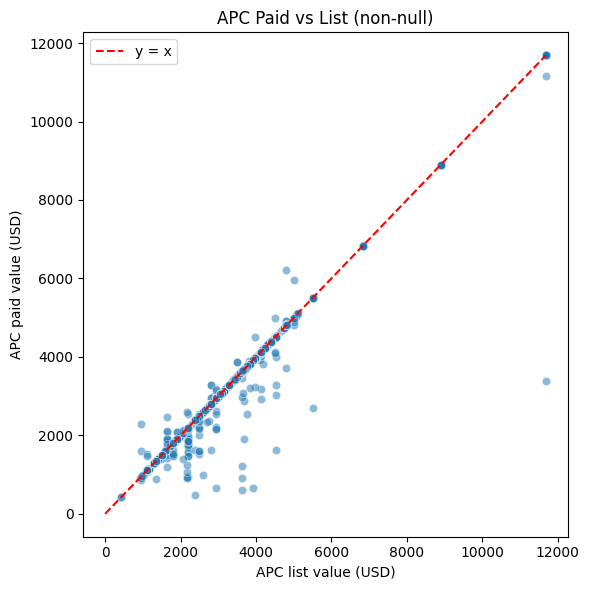

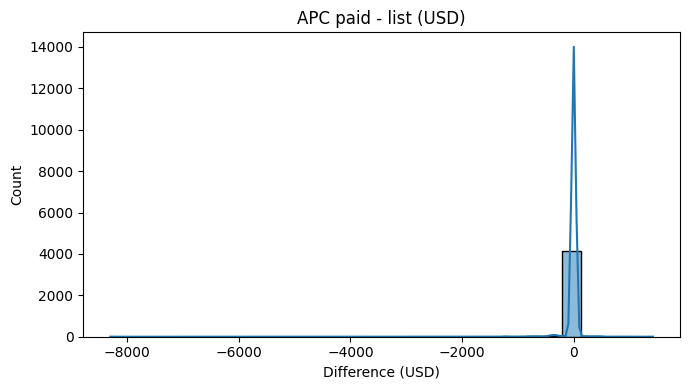

In [ ]:
# Compare APC list vs paid (missingness + agreement)
apc_cols = ["apc_list_value_usd", "apc_paid_value_usd"]
apc = raw_data_filtered[apc_cols].copy()



# Compare only rows with both values present
apc_nonnull = apc.dropna().copy()
apc_nonnull["apc_diff"] = apc_nonnull["apc_paid_value_usd"] - apc_nonnull["apc_list_value_usd"]
apc_nonnull["apc_abs_diff"] = apc_nonnull["apc_diff"].abs()
apc_nonnull["apc_pct_diff"] = apc_nonnull["apc_diff"] / apc_nonnull["apc_list_value_usd"].replace(0, np.nan)

# Treat values as matching within 1 cent
apc_nonnull["is_match"] = apc_nonnull["apc_abs_diff"] <= 0.01
print("\nMatch rate (<= $0.01):", apc_nonnull["is_match"].mean().round(3))




# Visuals: scatter with y=x line and diff distribution
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=apc_nonnull,
    x="apc_list_value_usd",
    y="apc_paid_value_usd",
    alpha=0.5
 )
max_val = apc_nonnull[apc_cols].max().max()
plt.plot([0, max_val], [0, max_val], linestyle="--", color="red", label="y = x")
plt.title("APC Paid vs List (non-null)")
plt.xlabel("APC list value (USD)")
plt.ylabel("APC paid value (USD)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(apc_nonnull["apc_diff"], bins=30, kde=True)
plt.title("APC paid - list (USD)")
plt.xlabel("Difference (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

is_oa
True     2700
False    1568
Name: count, dtype: int64


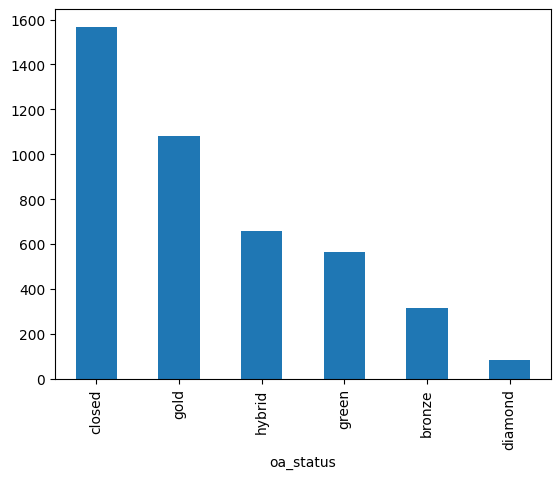

In [ ]:
print(raw_data_filtered.is_oa.value_counts())
raw_data_filtered.oa_status.value_counts()
raw_data_filtered.oa_status.value_counts().plot(kind='bar')
plt.show()


In [ ]:
#OpenAlex Id
print(raw_data_filtered.openalex_id.describe())
print(f'Duplicated ID: {raw_data_filtered.openalex_id.duplicated().sum()}')

count            4268
unique           3959
top       W3095638759
freq                9
Name: openalex_id, dtype: object
Duplicated ID: 309


In [ ]:
raw_data_filtered = raw_data_filtered.drop_duplicates(subset='openalex_id', keep='first')

# Verify
print(f"Rows remaining: {len(raw_data_filtered)}")
print(f"Duplicates remaining: {raw_data_filtered.openalex_id.duplicated().sum()}")

Rows remaining: 3959
Duplicates remaining: 0


count    406.000000
mean       9.751232
std       49.127646
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      939.000000
Name: count, dtype: float64


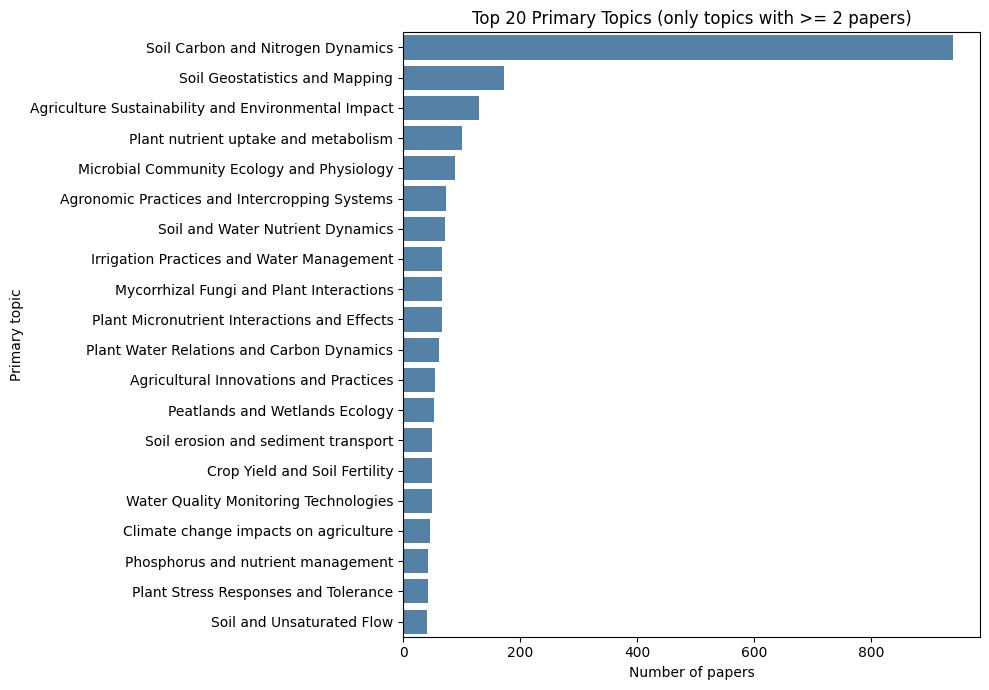

In [ ]:
# 1) Count topics
topic_counts = (raw_data_filtered["primary_topic_name"].value_counts())
print(topic_counts.describe())
# 2) Remove rare topics (example: keep topics with at least 2 papers)
min_count = 2
topic_counts_filtered = topic_counts[topic_counts >= min_count]
# 3) Keep top N for readability
top_n = 20
top_topics = topic_counts_filtered.head(top_n)
# 4) Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    orient="h",
    color="steelblue"
)
plt.title(f"Top {top_n} Primary Topics (only topics with >= {min_count} papers)")
plt.xlabel("Number of papers")
plt.ylabel("Primary topic")
plt.tight_layout()
plt.show()

In [ ]:
def extract_unique_sdg_names(x):
    if pd.isna(x):
        return None
    try:
        parsed = ast.literal_eval(x) if isinstance(x, str) else x
        if not isinstance(parsed, list):
            return None
        # canonical map: lowercase -> first seen "nice" casing
        canon = {}
        for d in parsed:
            if isinstance(d, dict):
                name = d.get("display_name")
                if isinstance(name, str):
                    clean = " ".join(name.split()).strip()          # remove extra spaces
                    key = clean.casefold()                           # case-insensitive key
                    if key and key not in canon:
                        canon[key] = clean.title()                   # standardize case
        if not canon:
            return None
        # sort so "A, B" and "B, A" become identical
        return ", ".join(sorted(canon.values()))
    except Exception:
        return None
raw_data_filtered["sdg_names"] = raw_data_filtered["sustainable_development_goals"].apply(extract_unique_sdg_names)

sdg_names_list
Life In Land                              1157
Zero Hunger                               1037
Clean Water And Sanitation                 321
Climate Action                             211
Responsible Consumption And Production     170
Life Below Water                           126
Sustainable Cities And Communities          31
No Poverty                                  21
Affordable And Clean Energy                 19
Industry                                    18
Innovation And Infrastructure               18
Partnerships For The Goals                  15
Good Health And Well-Being                  12
Peace                                        6
Justice And Strong Institutions              6
Name: count, dtype: int64


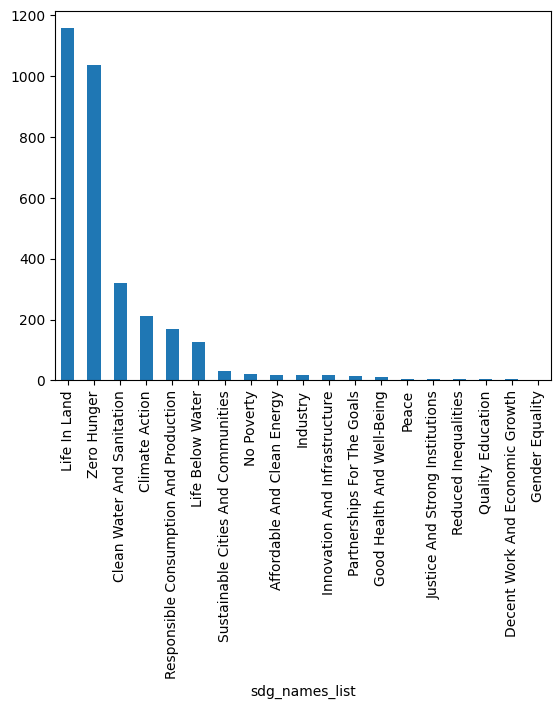

In [ ]:
def extract_unique_sdg_list(x):
    s = extract_unique_sdg_names(x)
    return s.split(", ") if isinstance(s, str) else []

raw_data_filtered["sdg_names_list"] = raw_data_filtered["sustainable_development_goals"].apply(extract_unique_sdg_list)

sdg_counts = (
    raw_data_filtered["sdg_names_list"]
    .explode()
    .dropna()
    .value_counts()
)

print(sdg_counts.head(15))
sdg_counts.plot(kind='bar')
plt.show()

count    3959.000000
mean     2020.533468
std         1.658375
min      2018.000000
25%      2019.000000
50%      2021.000000
75%      2022.000000
max      2023.000000
Name: publication_year, dtype: float64


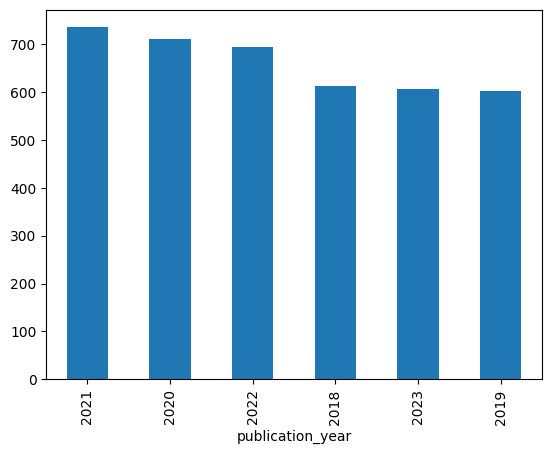

In [ ]:
print(raw_data_filtered.publication_year.describe())
raw_data_filtered.publication_year.value_counts().plot(kind='bar')
plt.show()


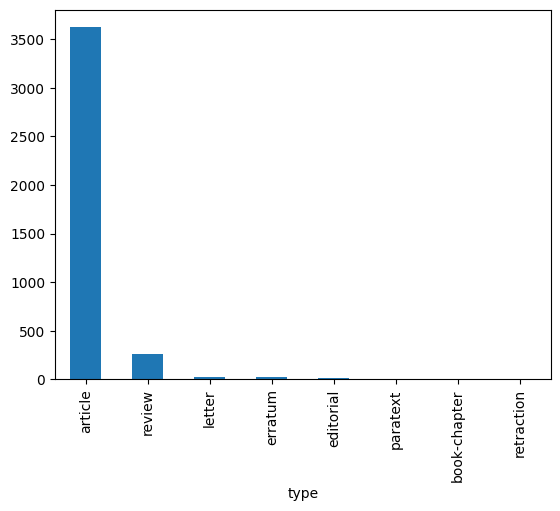

In [ ]:

raw_data_filtered.type.value_counts().plot(kind='bar')
plt.show()

count    3959.000000
mean       70.427128
std        52.007863
min         0.000000
25%        45.000000
50%        61.000000
75%        83.000000
max      1382.000000
Name: referenced_works_count, dtype: float64
referenced_works_count
0      96
60     75
61     73
53     70
50     67
       ..
254     1
220     1
171     1
207     1
362     1
Name: count, Length: 271, dtype: int64


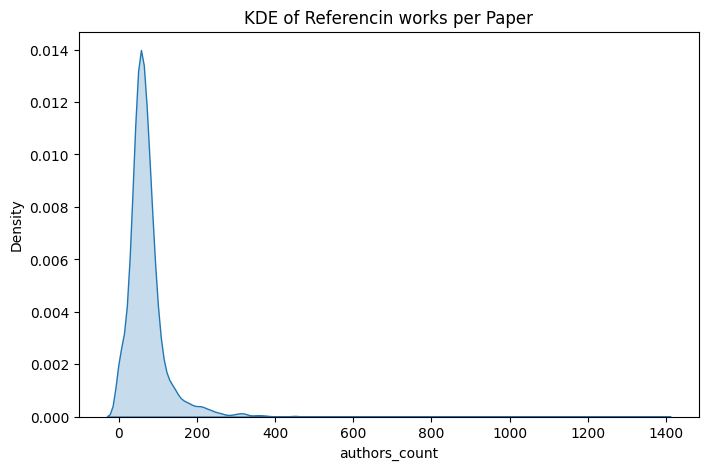

In [ ]:
#Yo mismo verifique el numero de referenced works y si es 1382
print(raw_data_filtered.referenced_works_count.describe())
print(raw_data_filtered.referenced_works_count.value_counts())
plt.figure(figsize=(8, 5))
sns.kdeplot(raw_data_filtered.referenced_works_count, fill=True, bw_adjust=1.0)
plt.title("KDE of Referencin works per Paper")
plt.xlabel("authors_count")
plt.ylabel("Density")
plt.show()

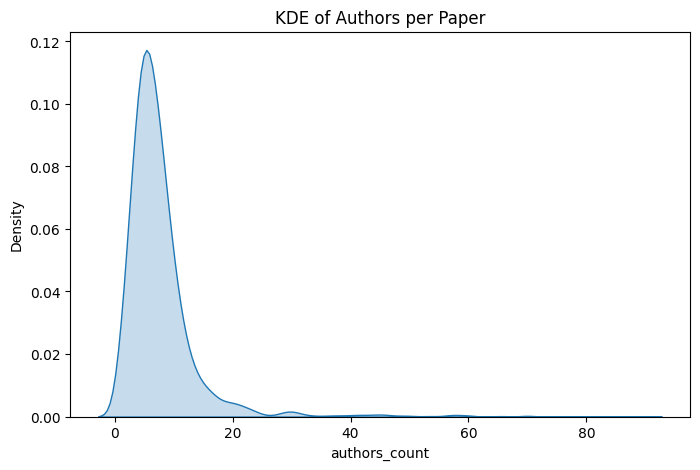

In [ ]:
authors = pd.to_numeric(raw_data_filtered["authors_count"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
sns.kdeplot(authors, fill=True, bw_adjust=1.0)
plt.title("KDE of Authors per Paper")
plt.xlabel("authors_count")
plt.ylabel("Density")
plt.show()

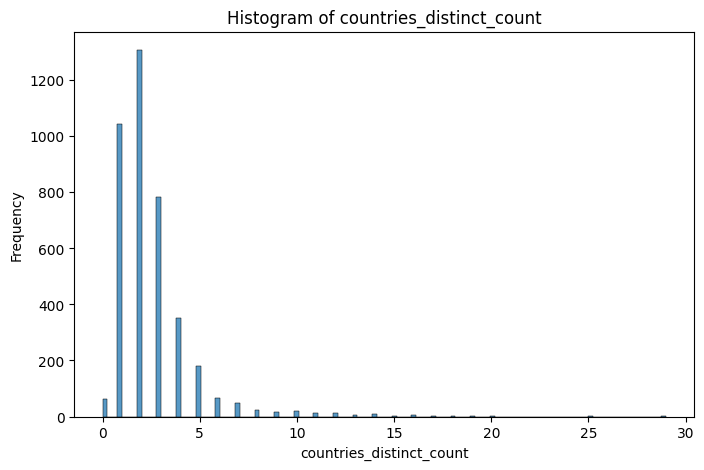

In [ ]:
countries = pd.to_numeric(raw_data_filtered["countries_distinct_count"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
sns.histplot(countries)
plt.title("Histogram of countries_distinct_count")
plt.xlabel("countries_distinct_count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# import ast
# import re

# # 1. Extract + normalize in one step
# def extract_keywords(keyword_str):
#     try:
#         data = ast.literal_eval(keyword_str)
#         cleaned = []
#         for item in data:
#             kw = item["display_name"].lower()
#             kw = re.sub(r"\(.*?\)", "", kw)  # remove parentheses
#             kw = kw.strip()
#             cleaned.append(kw)
#         return cleaned
#     except:
#         return []

# raw_data_filtered = raw_data_filtered.copy()  # IMPORTANT
# raw_data_filtered["keywords"] = raw_data_filtered["keywords"].apply(extract_keywords)


In [ ]:
print(raw_data_filtered.shape)
raw_data_filtered.to_csv('/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml')

(3959, 48)
